# ICT-Life — Substrat de calibration certifié : le Jeu de la Vie entre dans la batterie ICT

> **Série ICT** (Integrated Causal Trajectories, Epic #4588) — phase-zero « *Life as certified calibration substrate* » (issue #5726). Le Jeu de la Vie de Conway (règle **B3/S23** ; M. Gardner, *Mathematical Games*, Scientific American 1970) devient un substrat mesurable de la batterie ICT : une morphodynamique **2-D** à propagation d'information **localisée** — les gliders y jouent le rôle de « particules » transportant une information sur de grands horizons temporels. Et c'est la nouveauté qui fonde ce notebook : le calcul de trajectoire y est **certifié par une preuve formelle**. Le théorème `hashlife_correct`, entièrement prouvé en Lean 4 dans la track `conway_lean` (tracker #6724), garantit que l'évaluation **Hashlife** (quadtree mémoïsé, sauts temporels $2^k$) calcule *la même chose* que la simulation naïve pas-à-pas — celle-là même qu'implémente `ict.life`.

**Plan** :

1. La règle B3/S23 — la morphodynamique minimale (naissance, survie, mort, tore) ;
2. La **calibration canonique** — glider, blinker, pulsar, LWSS : périodes et déplacements vérifiés contre les constantes documentées ;
3. Le glider comme **particule d'information** — film, vitesse $c/4$, export au format d'états discrets de la batterie ;
4. Signatures de population — ce que chaque famille de pattern donne à mesurer ;
5. Le **pont Lean** — ce que `hashlife_correct` garantit exactement, et pourquoi la calibration Python reste nécessaire ;
6. Synthèse — le contraste avec les substrats S2 (bistable) et S5 (Gray-Scott), et la route vers le branchement batterie (`ict.agency`, `ict.stake`).

**Module** : `ict/life.py` (issue #5726, tranche 1-2, PR #11185). **Notebook pédagogique** : 3 exercices jalonnent le texte.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict.life import (
    CALIBRATION,
    calibrate_all,
    canonical_pattern,
    embed,
    live_cells,
    next_generation,
    period_and_displacement,
    trajectory,
)

print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

numpy 2.4.2 | matplotlib 3.10.8


## 1. La règle B3/S23 — la morphodynamique minimale

Sur une grille 2-D (tore : les bords sont recollés deux à deux), chaque cellule regarde ses 8 voisines de Moore :

* **B3** — une cellule **morte** ayant exactement 3 voisines vivantes **naît** ;
* **S23** — une cellule **vivante** ayant 2 ou 3 voisines vivantes **survit** ;
* tout le reste **meurt** (sous-population ou étouffement).

C'est tout. De cette règle locale émergent des objets globaux — oscillateurs, vaisseaux, gliders — sans qu'aucun ne soit programmé. Commençons par l'oscillateur minimal, le **blinker** : trois cellules en ligne qui basculent entre vertical et horizontal, indéfiniment.

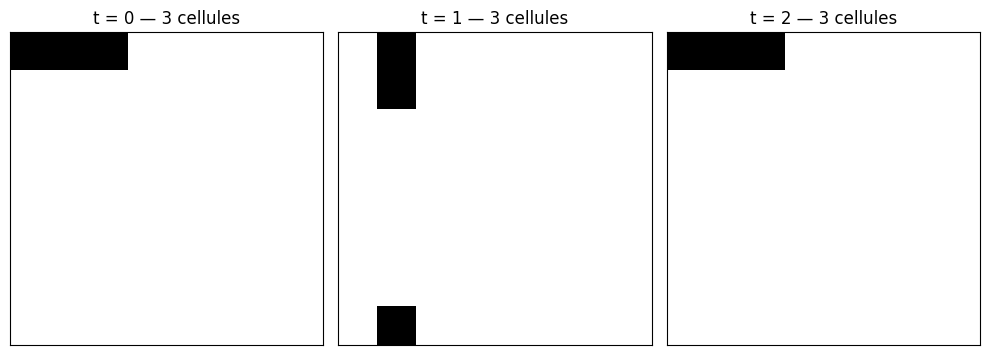

t = 0 : cellules vivantes = [(0, 0), (0, 1), (0, 2)]
t = 1 : cellules vivantes = [(0, 1), (1, 1), (7, 1)]
t = 2 : cellules vivantes = [(0, 0), (0, 1), (0, 2)]


In [2]:
blinker = embed(canonical_pattern("blinker"), 8)
film = trajectory(blinker, 2)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, g, t in zip(axes, film, range(3)):
    ax.imshow(g, cmap="Greys", vmin=0, vmax=1)
    ax.set_title(f"t = {t} — {int(g.sum())} cellules")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

for t, g in enumerate(film):
    print(f"t = {t} : cellules vivantes = {live_cells(g)}")

### Lecture du résultat

À $t=0$ le blinker est vertical (colonne 3) ; à $t=1$ il est horizontal (ligne 4) ; à $t=2$ il est redevenu vertical — **période 2**, exactement le comportement documenté. Les cellules qui naissent à $t=1$ sont celles qui avaient exactement 3 voisines ; les extrémités verticales (2 voisines chacune... en fait 1 voisine centrale + 0 latérale : sous-population) meurent. Le tore n'intervient pas ici, mais il garantit qu'aucun pattern ne « tombe » du bord : tout reste dans le système, ce qui compte pour mesurer des trajectoires longues.

### Exercice 1 — détecteur de still life

Un **still life** est un motif invariant par la règle : $\text{next}(g) = g$ (le bloc `OO / OO` en est le plus petit exemple). Écrivez le détecteur :

* *Indice* : comparez la grille à son successeur via `next_generation` ;
* *Étape 1* : calculer le successeur ;
* *Étape 2* : tester l'égalité exacte (attention au type : pensez à `np.array_equal`).

In [3]:
def est_still_life(grille):
    # Etape 1 : successeur de la grille sous B3/S23
    # Etape 2 : egalite exacte entre la grille et son successeur
    return None  # TODO etudiant

print("Exercice a completer : est_still_life (le bloc devrait repondre True)")

Exercice a completer : est_still_life (le bloc devrait repondre True)


## 2. La calibration canonique — le certificat du substrat

Le module `ict.life` embarque cinq patterns canoniques et leurs constantes documentées (LifeWiki, Berlekamp-Conway-Guy 1982, Catagolue). La fonction `calibrate_all()` rejoue chaque pattern dans le moteur B3/S23 et vérifie que la **période** et le **déplacement** mesurés coïncident avec les constantes attendues. C'est le **certificat de calibration** : s'il échoue, toute mesure ICT construite sur ce substrat est invalide.

In [4]:
print(f"{'pattern':<10}{'periode':>8}{'deplacement':>14}{'attendu':>24}{'verdict':>9}")
for nom, ok in calibrate_all().items():
    ref = CALIBRATION[nom]
    period, disp = period_and_displacement(embed(canonical_pattern(nom), 32), max_steps=64)
    attendu = f"p={ref['period']}, d={ref['displacement']}"
    print(f"{nom:<10}{period:>8}{str(disp):>14}{attendu:>24}{'OK' if ok else 'ECHEC':>9}")

pattern    periode   deplacement                 attendu  verdict
glider           4        (1, 1)           p=4, d=(1, 1)       OK
blinker          2        (0, 0)           p=2, d=(0, 0)       OK
pulsar           3        (0, 0)           p=3, d=(0, 0)       OK
lwss             4        (0, 2)           p=4, d=(0, 2)       OK
block            1        (0, 0)           p=1, d=(0, 0)       OK


### Lecture du résultat — et une honnêteté méthodologique

Les cinq verdicts sont **OK** : le moteur B3/S23 reproduit les constantes canoniques (blinker $p{=}2$ stationnaire, pulsar $p{=}3$ stationnaire, glider $p{=}4$ diagonal, LWSS $p{=}4$ orthogonal $c/2$, bloc $p{=}1$).

Le déplacement du **LWSS** mérite une note : la forme encodée dans le module n'a **pas** été copiée de mémoire (la première tentative, fautive, faisait diverger la population sans jamais cycler), mais **extraite empiriquement** — en faisant évoluer la synthèse officielle à 3 gliders du LWSS (Catagolue, objet `xq4_6frc`, règle B3/S23) dans le simulateur même, puis en isolant la phase à 9 cellules et en vérifiant ses constantes. La calibration n'est pas une cérémonie : c'est elle qui a attrapé l'erreur.

## 3. Le glider — une particule d'information

Le glider se déplace d'une case en diagonale toutes les 4 générations : vitesse $1/4$ case/génération ($c/4$, où $c$ est la « vitesse de la lumière » du Jeu de la Vie — une cellule par génération). Sa population reste **constante** (5 cellules) tandis que sa **forme est en translation** : c'est exactement ce qui en fait une *particule* — de l'information physiquement transportée sur un horizon long, la matière première que la batterie ICT veut mesurer (émergence causale macro/micro, surprise, MDL).

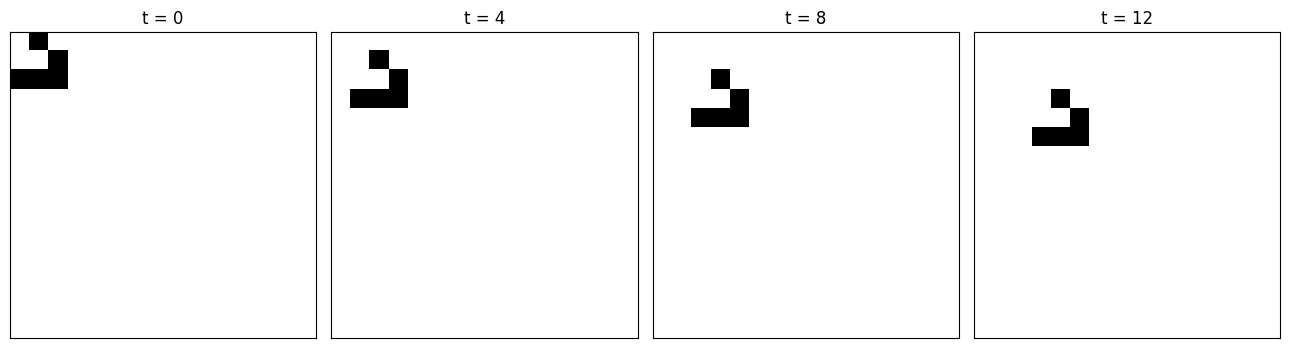

Glider : periode 4, deplacement (1, 1) -> vitesse diagonale 0.25 case/generation (c/4)
Export trajectoire (t=0), format etats discrets : [(0, 1), (1, 2), (2, 0), (2, 1), (2, 2)]


In [5]:
g0 = embed(canonical_pattern("glider"), 16)
film = trajectory(g0, 12)

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, t in zip(axes, (0, 4, 8, 12)):
    ax.imshow(film[t], cmap="Greys", vmin=0, vmax=1)
    ax.set_title(f"t = {t}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

p, d = period_and_displacement(embed(canonical_pattern("glider"), 32))
print(f"Glider : periode {p}, deplacement {d} -> vitesse diagonale {abs(d[0]) / p:.2f} case/generation (c/4)")
print("Export trajectoire (t=0), format etats discrets :", sorted(live_cells(film[0])))

### Lecture du résultat

À $t = 0, 4, 8, 12$, la même forme de 5 cellules apparaît décalée d'une case en diagonale à chaque période — la population est constante, la position avance. La dernière ligne montre le **format d'export** : la liste des cellules vivantes `(ligne, colonne)`, la représentation compacte d'un état discret directement consommable par les trajectoires ICT (`ict.trajectories`).

### Exercice 2 — la vitesse du LWSS

Le LWSS se déplace orthogonalement à $c/2$. Mesurez-le depuis la trajectoire elle-même :

* *Indice* : suivez l'origine de la boîte englobante (les indices des cellules vivantes, `np.nonzero`, donnent le coin) entre $t=0$ et $t = 4\,n$ ;
* *Étape 1* : construire la trajectoire du LWSS sur 8 périodes (32 générations) ;
* *Étape 2* : déplacement total ÷ temps total, en cases/génération — attendu : $0{,}5$.

In [6]:
def vitesse_lwss(n_periodes=8):
    # Etape 1 : trajectoire du LWSS sur n_periodes * 4 generations
    # Etape 2 : deplacement du coin de la boite englobante / temps ecoule
    return None  # TODO etudiant

print("Exercice a completer : vitesse_lwss (attendu 0.5 case/generation, c/2)")

Exercice a completer : vitesse_lwss (attendu 0.5 case/generation, c/2)


## 4. Signatures de population — ce que chaque famille donne à mesurer

Oscillateurs et vaisseaux n'occupent pas le même coin de l'espace des trajectoires : les premiers bornent une population oscillante *sur place*, les seconds maintiennent une population constante *en translation*. La courbe de population le long du film est déjà une signature mesurable — le premier scalre que la batterie ICT pourra suivre le long d'une trajectoire GOL.

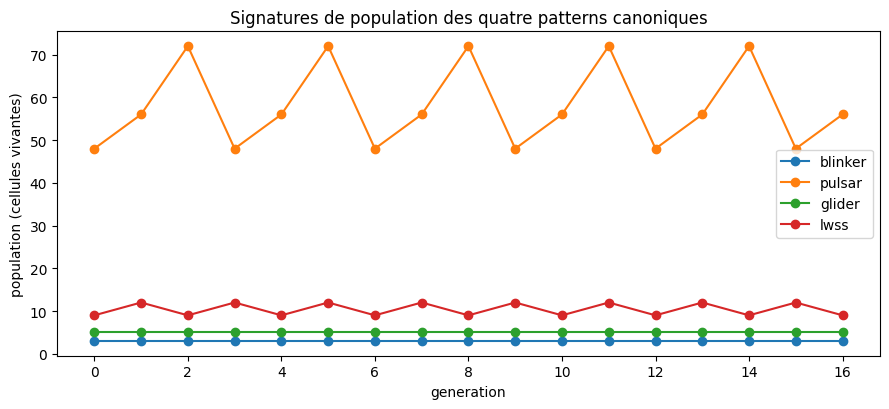

blinker  population min=3   max=3   finale=3
pulsar   population min=48  max=72  finale=56
glider   population min=5   max=5   finale=5
lwss     population min=9   max=12  finale=9


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
resumes = {}
for nom, taille in (("blinker", 8), ("pulsar", 32), ("glider", 16), ("lwss", 32)):
    film = trajectory(embed(canonical_pattern(nom), taille), 16)
    pops = [int(g.sum()) for g in film]
    resumes[nom] = (min(pops), max(pops), pops[-1])
    ax.plot(range(len(pops)), pops, marker="o", label=nom)
ax.set_xlabel("generation")
ax.set_ylabel("population (cellules vivantes)")
ax.set_title("Signatures de population des quatre patterns canoniques")
ax.legend()
plt.tight_layout()
plt.show()

for nom, (mn, mx, fin) in resumes.items():
    print(f"{nom:<8} population min={mn:<3} max={mx:<3} finale={fin}")

### Lecture du résultat — le contraste des trois substrats

Deux régimes nets : les **oscillateurs** (blinker, pulsar) présentent une population **oscillante bornée** — un attracteur périodique local ; les **vaisseaux** (glider, LWSS) maintiennent une population **exactement constante** (5 et 9) pendant que leur forme se translate. C'est ce second régime — information transportée — que ni le bistable ni la réaction-diffusion ne fournissent :

| Substrat | Notebook | Dimension | Attracteurs | Information localisée transportée | Certification |
|---|---|---|---|---|---|
| Paturage de May (bistable) | ICT-8 | 0-D continu | 2 puits (bifurcation pli) | non (pas d'espace) | — |
| Gray-Scott | ICT-9 | 2-D continu | motifs Turing auto-entretenus | non (morphogenèse sans particule stable) | — |
| **Jeu de la Vie (B3/S23)** | ce notebook | **2-D discret** | oscillateurs + vaisseaux | **oui** (glider $c/4$, LWSS $c/2$) | **Lean `hashlife_correct`** (#6724) |

Le Jeu de la Vie est le seul des trois à offrir des **trajectoires longues d'objets transporteurs** — et le seul dont le moteur de calcul est **prouvé correct**.

## 5. Le pont Lean — ce que `hashlife_correct` garantit exactement

La track `conway_lean` (`MyIA.AI.Notebooks/SymbolicAI/Lean/conway_lean/`) formalise l'algorithme **Hashlife** de Gosper — évaluation par quadtree mémoïsé avec sauts temporels $2^k$. Le théorème central, dans `Conway/Life/HashlifeCorrectness.lean` :

> **`hashlife_correct`** — pour toute grille et tout horizon, sous l'hypothèse de capture de trajectoire (re-signature b3'), l'évaluation Hashlife et la simulation naïve pas-à-pas produisent **le même film**.

Ce théorème est **entièrement prouvé** (plus aucun `sorry` dans `HashlifeCorrectness.lean`), au terme d'une chaîne fermée pierre par pierre : `LightCone.lean` (PR #5917), la racine P4 `p4_succ_membership`, le pont de localité BR1-BR3, le saut unitaire BR4a `one_jump_toGrid_correct` (PR #10919), et la décharge de `p5_large_n_jumpN` par induction sur le fuel (PR #11007). Seul `HashlifeMarginFragment.lean` garde un `sorry` documenté comme intrinsèque (#9568), hors de la chaîne du théorème.

**Pourquoi la calibration Python reste nécessaire** : le théorème Lean garantit l'*égalité* Hashlife ↔ naïf **dans le monde formel** — il ne garantit pas que l'implémentation Python de la branche naïve est fidèle à la règle B3/S23. Cette fidélité, c'est la calibration de la section 2 qui l'établit, contre les constantes canoniques des patterns. Les deux jambes ensemble fondent le substrat : un moteur **vérifié** (calibration) dont l'accélération éventuelle est **prouvée inoffensive** (Lean). Vérifions l'état du gate sur l'arbre courant :

In [8]:
from pathlib import Path

def _trouver_lean():
    candidats = [
        Path("../../../SymbolicAI/Lean/conway_lean/Conway/Life/HashlifeCorrectness.lean"),
        Path("../../SymbolicAI/Lean/conway_lean/Conway/Life/HashlifeCorrectness.lean"),
    ]
    for c in candidats:
        if c.exists():
            return c
    return None

chemin = _trouver_lean()
if chemin is None:
    print("Fichier Lean introuvable depuis ce notebook (checkout partiel).")
else:
    lignes = chemin.read_text(encoding="utf-8").splitlines()
    sorries = sum(1 for l in lignes if l.strip() == "sorry")
    thm = [l.strip() for l in lignes if "theorem hashlife_correct" in l]
    print(f"Fichier : {chemin}")
    print(f"Lignes : {len(lignes)}")
    print(f"Lignes 'sorry' (niveau code) : {sorries}")
    for t in thm:
        print("Declaration :", t[:90])

Fichier : ..\..\SymbolicAI\Lean\conway_lean\Conway\Life\HashlifeCorrectness.lean
Lignes : 1634
Lignes 'sorry' (niveau code) : 0
Declaration : theorem hashlife_correct (n : Nat) (g : Grid) (h : box_assez_grand g n) :
Declaration : theorem hashlife_correct_base_zero (g : Grid) :
Declaration : theorem hashlife_correct (n : Nat) (g : Grid) (h : BoxAssezGrand g n) :
Declaration : theorem hashlife_correctN (n : Nat) (g : Grid)
Declaration : theorem hashlife_correctN_le_two (n : Nat) (g : Grid) (hn : n ≤ 2)
Declaration : theorem hashlife_correct_implies_block_2
Declaration : theorem hashlife_correct_implies_glider_2
Declaration : theorem hashlife_correct_implies_blinker_h_2
Declaration : theorem hashlife_correct_implies_toad_2
Declaration : theorem hashlife_correct_implies_beacon_2


### Lecture du résultat

Le fichier `HashlifeCorrectness.lean` de l'arbre contient les déclarations de `hashlife_correct` (cas de base) et `hashlife_correctN` (horizon arbitraire), et **zéro** ligne `sorry` au niveau code : le gate qui bloquait l'entrée du Jeu de la Vie dans l'ICT (issue #5726, « dépendance dure ») est levé. Les trajectoires exportées depuis `ict.life` héritent donc de la garantie complète : moteur calibré (sections 2-4) + égalité Hashlife/naïf prouvée (cette section).

## 6. Synthèse — et la suite

**Ce notebook boucle la phase-zero « *Life as certified calibration substrate* » de l'issue #5726** :

1. **Export des trajectoires** — `trajectory` + `live_cells` (états discrets, section 3) ;
2. **`ict/life.py`** — le substrat (PR #11185, tranches 1-2) ;
3. **Ce notebook de calibration** — glider / blinker / pulsar / LWSS sur patterns canoniques ;
4. **Le fil bouclé** — `hashlife_correct` cité comme garantie de correction du calcul de trajectoire (section 5).

La suite (phases narratives de #5726) : brancher ces trajectoires sur la batterie — `ict.agency`, `ict.stake`, émergence causale multi-échelle à la Hoel — avec le glider comme « particule » et le contraste S2/S5/Life comme plan expérimental.

### Exercice 3 — collision de deux gliders

La collision de deux gliders produit un débris stable (blocs + blinker) — un événement *local* et *irréversible* dans le film. Caractérisez-le :

* *Indice* : placez un glider canonique et son miroir horizontal (`np.flip(..., axis=1)`) sur des trajectoires qui se croisent ;
* *Étape 1* : construire la grille (deux `embed`, ou un seul puis écrire le miroir dedans) ;
* *Étape 2* : évoluer ~40 générations et repérer la stabilisation (population périodique) ;
* *Étape 3* : retourner le nombre de cellules vivantes finales et la période de l'état final.

In [9]:
def collision_deux_gliders():
    # Etape 1 : grille avec un glider et son miroir horizontal en trajectoire de collision
    # Etape 2 : evoluer ~40 generations, detecter la stabilisation (population periodique)
    # Etape 3 : retourner (population finale, periode de l'etat final)
    return None  # TODO etudiant

print("Exercice a completer : collision_deux_gliders")

Exercice a completer : collision_deux_gliders
